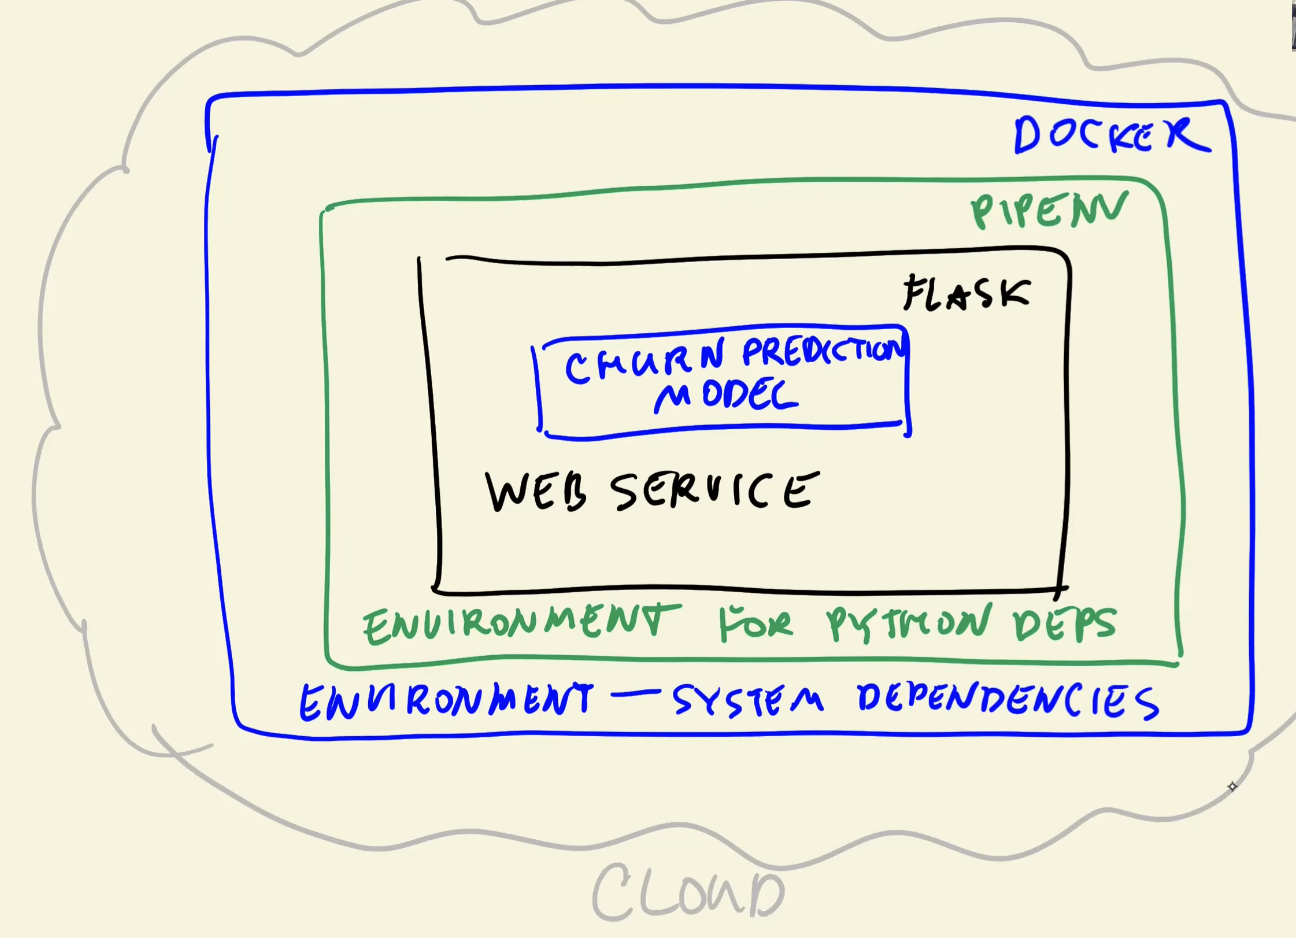

# **Note**

1. The train.py file creates a model and save it in this directory
2. the ping.py file shows an introduction of flask and the usage of simple route
3. The predict.py file will use the machine learning model and will return the prediction

In [1]:
import requests

In [2]:
url = 'http://localhost:9696/predict'

In [4]:
customer = {"gender": "male",
 "seniorcitizen": 0,
 "partner": "no",
 "dependents": "yes",
 "phoneservice": "yes",
 "multiplelines": "no",
 "internetservice": "no",
 "onlinesecurity": "no_internet_service",
 "onlinebackup": "no_internet_service",
 "deviceprotection": "no_internet_service",
 "techsupport": "no_internet_service",
 "streamingtv": "no_internet_service",
 "streamingmovies": "no_internet_service",
 "contract": "month-to-month",
 "paperlessbilling": "yes",
 "paymentmethod": "mailed_check",
 "tenure": 1,
 "monthlycharges": 20.25,
 "totalcharges": 20.25}

In [ ]:
# sending the customer to the predict route of the url


In [5]:
requests.post(url, json=customer)

<Response [200]>

Response 200 is successful

In [ ]:
# Getting the prediction using .json()
response = requests.post(url, json=customer).json()
response

{'churn': False, 'churn_probability': 0.24919950332834653}

In [ ]:
if response['churn'] == True:
    print('''This customer has high probability of churning.
           Send promotional email to him''')

## **Using gunicorn**

After pip installing it, you have to run:

gunicorn --bind 0.0.0.0:9696 predict:app

### **Environment and Dependency Management**

1. pip install pipenv
2. pipenv install numpy scikit-learn flask gunicorn

After running Pipfile and Pipfile.lock will automatically created

3. To start the newly created environment just run: pipenv shell or to run gunicorn right away: pipenv run gunicorn --bind 0.0.0.0:9696 predict:app

## **Docker**

Find a docker python image based on your requirements in the pipfile. Mine is python >= 3.13

In [ ]:
1. Run the docker on your local machine
2. Run on the terminal: docker run -it --rm python:3.13.4-slim
3. Going inside the image: docker run -it --rm --entrypoint=bash python:3.13.4-slim
4. run:apt-get update,  apt-get install wget 

Better way to do that

1. Create a Dockerfile
2. Start it with FROM to know which image are you pertaining to 
3. Put codes and script into it 
4. Once done, on that same directory run:  docker build -t <name-of-image> .
5. Since you have created a docker image based on your likings already, you can now run it: docker run -it --rm --entrypoint=bash mlzoomcamp-test1
6. Once done, you are now inside the image and you can test it by running ls. 

Lets say you add more instruction to the dockerfile. In order to see this modification, you need to build the model again
7. docker build -t <name-of-image> .
8. Once finish building, you can start it again: docker run -it --rm --entrypoint=bash mlzoomcamp-test1
9. Copy the predict.py and model_C=1.0.bin and paste it to the docker image
10. run: gunicorn --bind=0.0.0.0:9696 predict:app

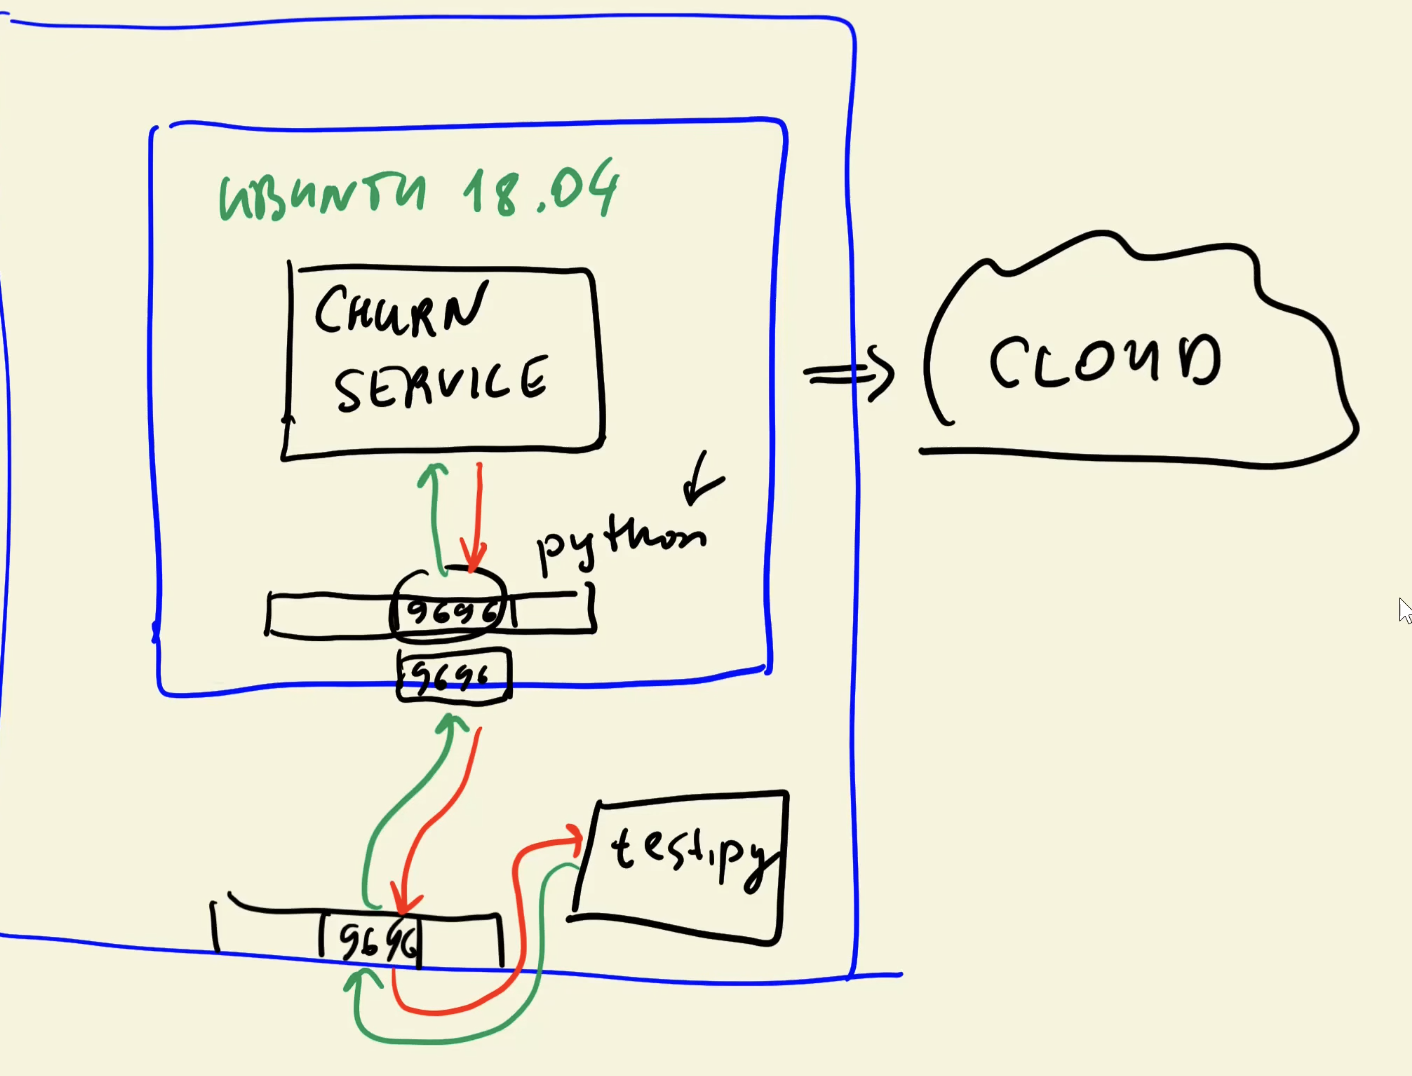

11. In the dockerfile expose the port so that you can access it on your local machine 
12. Also add entry point
13. Once done, build the docker then running it with: docker run -it --rm -p 9696:9696 mlzoomcamp-test1
